<a href="https://colab.research.google.com/github/AvyayaKumar/zthkarp/blob/main/micrograd_with_karpathy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install graphviz

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [ ]:
def f(x):
    return 3*x**2 - 4*x + 5

In [ ]:
f(3.0)

20.0

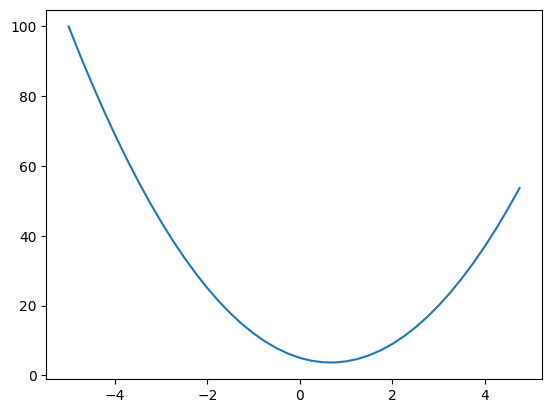

In [ ]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [ ]:
#limit
h = 0.0001

a = 4
b = -9
c = 3
d = a*b + c
c += h
d2 = a*b + c
print('d1', d)
print('d2', d2)
print('slope', (d2-d)/h)

d1 -33
d2 -32.9999
slope 1.0000000000331966


In [170]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):  # other + self
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        # self.grad = other.data
        # other.grad = self.data
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    # hello
    def __rmul__(self, other):
        return self * other

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += out.grad * out.data * other * (self.data ** -1)
        out._backward = _backward

        return out

    # hello
    def __neg__(self): # -self
        return self * -1
    # hello
    def __sub__(self, other): # self - other
        return self + (-other)
    # hello
    def __truediv__(self, other): # self / other
        other = other if isinstance(other, Value) else Value(other)
        return self * other**-1

    def tanh(self):
        n = self.data
        t = (math.exp(2*n)-1) / (math.exp(2*n)+1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1-t*t) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [ ]:
a = Value(2.0)
b = Value(4.0)
a - b

Value(data=-2.0)

In [ ]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [ ]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

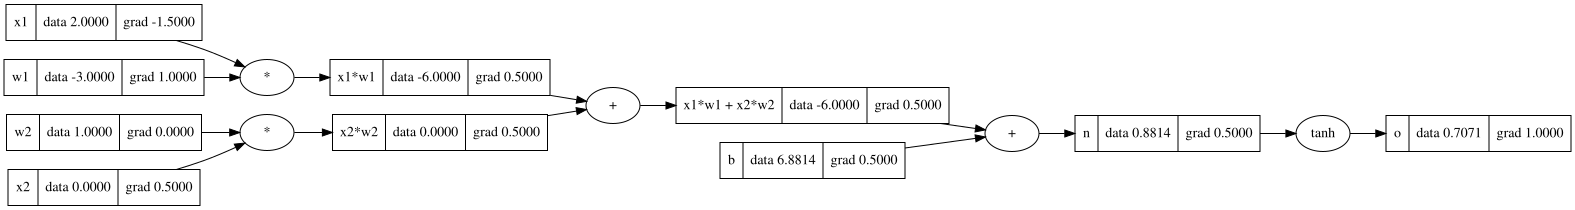

In [ ]:
o.backward()
draw_dot(o)

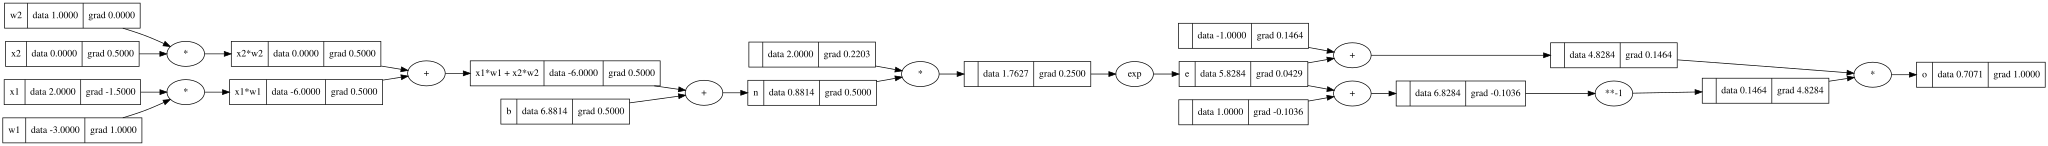

In [ ]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# -----------
e = (2*n).exp(); e.label = 'e'
o = (e-1)/(e+1)
# -----------
o.label = 'o'
o.backward()
draw_dot(o)

In [ ]:
import torch

x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

In [167]:
import random

In [237]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        #w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layers in self.layers for p in layers.parameters()]


In [403]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
#n is now a neural net that takes in 3 inputs, puts it thru layers of randomly generated weights and biases, and gets an output
n(x)

Value(data=-0.3202892659855082)

In [404]:
len(n.parameters())

41

In [405]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [411]:
for k in range(200):

    ypred = [n(x) for x in xs]
    loss = sum([(yout-ygt)**2 for ygt, yout in zip(ys, ypred)])
    for p in n.parameters():
        p.grad = 0.0

    loss.backward()
    for p in n.parameters():
        p.data += -1 * p.grad

    print(k, loss.data)


0 0.0001703054505148479
1 0.0001694196627733195
2 0.00016854278788161746
3 0.00016767469378236105
4 0.00016681525099371605
5 0.0001659643325472462
6 0.00016512181392752602
7 0.0001642875730135185
8 0.0001634614900215497
9 0.00016264344744998285
10 0.0001618333300254048
11 0.00016103102465029912
12 0.00016023642035225015
13 0.00015944940823448093
14 0.00015866988142783578
15 0.00015789773504402524
16 0.0001571328661301758
17 0.00015637517362464834
18 0.00015562455831398926
19 0.00015488092279112678
20 0.00015414417141463912
21 0.0001534142102691279
22 0.00015269094712666033
23 0.0001519742914092376
24 0.0001512641541522322
25 0.00015056044796882596
26 0.0001498630870153529
27 0.0001491719869575566
28 0.00014848706493772947
29 0.0001478082395427069
30 0.00014713543077267692
31 0.00014646856001079888
32 0.00014580754999358832
33 0.0001451523247820864
34 0.00014450280973371283
35 0.00014385893147489411
36 0.00014322061787430134
37 0.00014258779801684012
38 0.00014196040217823392
39 0.00014

In [412]:
ypred

[Value(data=0.9973051724695554),
 Value(data=-0.9977766758719662),
 Value(data=-0.993419693250666),
 Value(data=0.9947942486585604)]